In [132]:
import cv2  #opencv读取的格式是BGR
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
%matplotlib inline

def cv_show(name, img):
    cv2.imshow('pig', img)  #image弹出的图片展示窗口名称，img为对象名
    cv2.waitKey(0)  #按任意键退出
    cv2.destroyAllWindows()

img_lin=cv2.imread('lin.jpg', cv2.IMREAD_GRAYSCALE)


In [133]:
#卷积核
kernel=np.ones((5,5),np.uint8)
erosion=cv2.erode(img_lin,kernel,iterations=1) #腐蚀,迭代操作1次
erosion_two=cv2.erode(img_lin,kernel,iterations=2) #腐蚀,迭代操作2次
#腐蚀即是把一个白点周围若存在黑点那么直接腐蚀成黑点，所以会越来越细

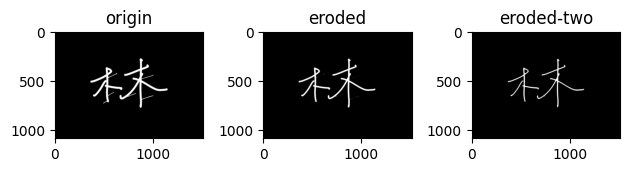

In [134]:
plt.subplot(131),plt.imshow(img_lin,'gray'),plt.title('origin')
plt.subplot(132),plt.imshow(erosion,'gray'),plt.title('eroded')
plt.subplot(133),plt.imshow(erosion_two,'gray'),plt.title('eroded-two')
plt.tight_layout() #自动优化子图间的距离

In [135]:
#膨胀
lin_dilate=cv2.dilate(erosion_two,kernel,iterations=1)
lin_dilate_two=cv2.dilate(erosion_two,kernel,iterations=2)
#腐蚀即是把一个黑点周围若存在白点那么直接膨胀成白点，所以会越来粗

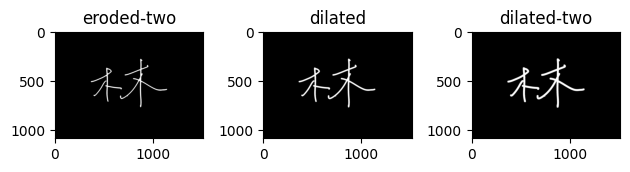

In [136]:
plt.subplot(131),plt.imshow(erosion_two,'gray'),plt.title('eroded-two')
plt.subplot(132),plt.imshow(lin_dilate,'gray'),plt.title('dilated')
plt.subplot(133),plt.imshow(lin_dilate_two,'gray'),plt.title('dilated-two')
plt.tight_layout() #自动优化子图间的距离

(<Axes: title={'center': 'opening'}>,
 Text(0.5, 1.0, 'opening'))

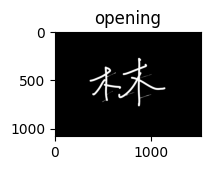

In [137]:
#开运算：先腐蚀，再膨胀

kernel=np.ones((5,5),np.uint8)
opening=cv2.morphologyEx(img_lin,cv2.MORPH_OPEN,kernel)

plt.subplot(131),plt.imshow(opening,'gray'),plt.title('opening')

(<Axes: title={'center': 'closing'}>,
 Text(0.5, 1.0, 'closing'))

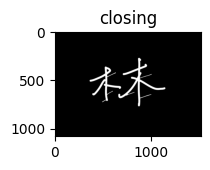

In [138]:
#闭运算：先膨胀，再腐蚀

kernel=np.ones((5,5),np.uint8)
closing=cv2.morphologyEx(img_lin,cv2.MORPH_CLOSE,kernel)
plt.subplot(131),plt.imshow(closing,'gray'),plt.title('closing')
#毛刺依旧明显

In [139]:
#梯度运算的原理
img_mount=imread('mount.jpg',cv2.IMREAD_GRAYSCALE)
kernel=np.ones((7,7),np.uint8)
mount_dilate5=cv2.dilate(img_mount,kernel,iterations=5)
mount_erosion5=cv2.erode(img_mount,kernel,iterations=5)
#轮廓就是：膨胀-腐蚀

#所以梯度运算就是
mount_gradient=cv2.morphologyEx(img_mount,cv2.MORPH_GRADIENT,kernel)

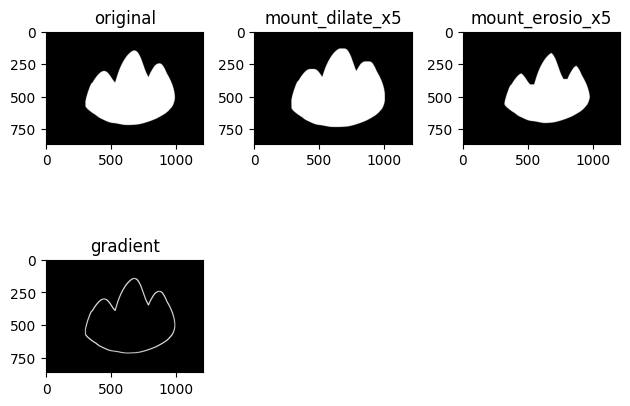

In [140]:
plt.subplot(231),plt.imshow(img_mount,'gray'),plt.title('original')
plt.subplot(232),plt.imshow(mount_dilate5,'gray'),plt.title('mount_dilate_x5')
plt.subplot(233),plt.imshow(mount_erosion5,'gray'),plt.title('mount_erosio_x5')
plt.subplot(234),plt.imshow(mount_gradient,'gray'),plt.title('gradient')
plt.tight_layout() #自动优化子图间的距离

In [141]:
#礼帽与黑帽
#礼帽=原始输入-开运算结果
#黑帽=闭运算-原始输入

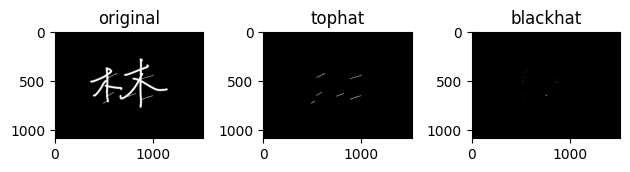

In [142]:
#礼帽 :有刺-没刺
#剩毛刺
tophat=cv2.morphologyEx(img_lin,cv2.MORPH_TOPHAT,kernel)
plt.subplot(231),plt.imshow(img_lin,'gray'),plt.title('original')
plt.subplot(232),plt.imshow(tophat,'gray'),plt.title('tophat')
#黑帽：留下轮廓
blackhat=cv2.morphologyEx(img_lin,cv2.MORPH_BLACKHAT,kernel)
plt.subplot(233),plt.imshow(blackhat,'gray'),plt.title('blackhat')
plt.tight_layout()